# DiffusionDrive Model Output Visualization

This notebook provides tools to visualize and analyze the outputs of trained DiffusionDrive models.

## Model Outputs
1. **Trajectory Prediction**: 8 future waypoints (4 seconds at 0.5s intervals)
2. **Agent Detection**: Up to 30 detected agents with bounding boxes
3. **BEV Semantic Segmentation**: 7-class semantic map

## 1. Setup and Imports

In [13]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from matplotlib import animation
from IPython.display import HTML, display
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import pickle
from tqdm import tqdm

# Add parent directory to path
sys.path.append(os.path.dirname(os.getcwd()))

# NavSim imports
from navsim.common.dataloader import SceneLoader
from navsim.agents.diffusiondrive.transfuser_agent import TransfuserAgent
from navsim.agents.diffusiondrive.transfuser_config import TransfuserConfig
from navsim.common.dataclasses import AgentInput, Trajectory

# Set environment variables
os.environ['NAVSIM_DEVKIT_ROOT'] = '/workspace/DiffusionDrive'
os.environ['NAVSIM_EXP_ROOT'] = '/workspace/navsim_workspace'

# Plotting settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (15, 8)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu126
CUDA available: True
CUDA device: NVIDIA H100 80GB HBM3


## 2. Model Loading

In [14]:
# Verify required files exist
import os

# Check for required model files
required_files = {
    'Pretrained Backbone': '/workspace/DiffusionDrive/download/pytorch_model.bin',
    'Trajectory Anchors': '/workspace/DiffusionDrive/download/kmeans_navsim_traj_20.npy',
}

print("Checking required files:")
for name, path in required_files.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {name}: {path} ({size_mb:.2f} MB)")
    else:
        print(f"✗ {name}: {path} NOT FOUND")

# Check checkpoint
checkpoint_path = '/workspace/navsim_workspace/exp/training_diffusiondrive_agent_testOnNewTorchVersion_bs64_ep400/2025.07.05.15.58.19/lightning_logs/version_0/checkpoints/epoch=209-step=35070.ckpt'
if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"✓ Model Checkpoint: {checkpoint_path} ({size_mb:.2f} MB)")
else:
    print(f"✗ Model Checkpoint: {checkpoint_path} NOT FOUND")
    print("Available checkpoints:")
    checkpoint_dir = os.path.dirname(checkpoint_path)
    if os.path.exists(checkpoint_dir):
        for f in os.listdir(checkpoint_dir):
            if f.endswith('.ckpt'):
                print(f"  - {f}")

Checking required files:
✓ Pretrained Backbone: /workspace/DiffusionDrive/download/pytorch_model.bin (0.06 MB)
✓ Trajectory Anchors: /workspace/DiffusionDrive/download/kmeans_navsim_traj_20.npy (0.00 MB)
✓ Model Checkpoint: /workspace/navsim_workspace/exp/training_diffusiondrive_agent_testOnNewTorchVersion_bs64_ep400/2025.07.05.15.58.19/lightning_logs/version_0/checkpoints/epoch=209-step=35070.ckpt (695.73 MB)


In [15]:
# Model checkpoint path
CHECKPOINT_PATH = '/workspace/navsim_workspace/exp/training_diffusiondrive_agent_testOnNewTorchVersion_bs64_ep400/2025.07.05.15.58.19/lightning_logs/version_0/checkpoints/epoch=209-step=35070.ckpt'

# Paths to required model files
PRETRAINED_BACKBONE_PATH = '/workspace/DiffusionDrive/download/pytorch_model.bin'
TRAJECTORY_ANCHORS_PATH = '/workspace/DiffusionDrive/download/kmeans_navsim_traj_20.npy'

def load_model(checkpoint_path: str, device: str = 'cuda'):
    """Load DiffusionDrive model from checkpoint."""
    print(f"Loading model from: {checkpoint_path}")
    
    # Create config with correct paths
    config = TransfuserConfig()
    config.bkb_path = PRETRAINED_BACKBONE_PATH
    config.plan_anchor_path = TRAJECTORY_ANCHORS_PATH
    
    # Initialize agent with learning rate (not used during inference)
    agent = TransfuserAgent(
        checkpoint_path=None,  # Don't load in __init__ to avoid double loading
        config=config,
        lr=6e-4  # Default learning rate from DiffusionDrive config
    )
    
    # Load checkpoint manually
    print("Loading checkpoint...")
    if torch.cuda.is_available():
        checkpoint = torch.load(checkpoint_path)
    else:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    
    # Extract state dict and remove 'agent.' prefix
    state_dict = checkpoint['state_dict']
    state_dict = {k.replace('agent.', ''): v for k, v in state_dict.items()}
    
    # Load state dict
    missing_keys, unexpected_keys = agent.load_state_dict(state_dict, strict=False)
    
    if missing_keys:
        print(f"Missing keys: {len(missing_keys)} keys")
        if len(missing_keys) < 10:
            print(f"Missing keys: {missing_keys}")
    if unexpected_keys:
        print(f"Unexpected keys: {len(unexpected_keys)} keys")
        if len(unexpected_keys) < 10:
            print(f"Unexpected keys: {unexpected_keys}")
    
    # Move to device
    agent.to(device)
    agent.eval()
    
    print("Model loaded successfully!")
    return agent

# Load the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = load_model(CHECKPOINT_PATH, device)

Loading model from: /workspace/navsim_workspace/exp/training_diffusiondrive_agent_testOnNewTorchVersion_bs64_ep400/2025.07.05.15.58.19/lightning_logs/version_0/checkpoints/epoch=209-step=35070.ckpt


No checkpoint path provided. Initializing from scratch.
Loading checkpoint...
Model loaded successfully!


## 3. Data Loading

In [16]:
# Load validation dataset from cache
from pathlib import Path
import gzip

# Define cache directory
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")

# Helper functions for loading data
def load_sample(sequence_path, token_idx=0):
    """Load a single feature-target pair from cache."""
    tokens = sorted([d for d in sequence_path.iterdir() if d.is_dir()])
    if token_idx >= len(tokens):
        print(f"Token index {token_idx} out of range (max: {len(tokens)-1})")
        return None, None
    
    token_path = tokens[token_idx]
    
    # Load features
    with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
        features = pickle.load(f)
    
    # Load targets
    with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
        targets = pickle.load(f)
    
    return features, targets

def load_multiple_samples(n_samples=100):
    """Load multiple samples from cache for visualization."""
    sequences = sorted([d for d in base_cache_dir.iterdir() if d.is_dir()])
    print(f"Found {len(sequences)} sequences in cache")
    
    all_features = []
    all_targets = []
    
    sample_count = 0
    for seq in sequences:
        tokens = sorted([d for d in seq.iterdir() if d.is_dir()])
        for token_path in tokens:
            if sample_count >= n_samples:
                break
                
            try:
                # Load features
                with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
                    features = pickle.load(f)
                
                # Load targets
                with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
                    targets = pickle.load(f)
                    
                all_features.append(features)
                all_targets.append(targets)
                sample_count += 1
                
            except Exception as e:
                print(f"Error loading {token_path}: {e}")
                continue
                
        if sample_count >= n_samples:
            break
    
    print(f"Loaded {len(all_features)} samples")
    return all_features, all_targets

# Load samples for visualization
print("Loading samples from cache...")
cached_features, cached_targets = load_multiple_samples(n_samples=50)

Loading samples from cache...
Found 1192 sequences in cache
Loaded 50 samples


## 4. Model Inference Function

In [17]:
def run_model_inference(model, transfuser_feature: Dict, transfuser_target: Optional[Dict] = None):
    """
    Run model inference on a single sample.
    
    Returns:
        dict: Model predictions with keys:
            - trajectory: [8, 3] predicted waypoints
            - agent_states: [30, 5] predicted agent bounding boxes
            - agent_labels: [30] agent detection scores
            - bev_semantic_map: [7, H, W] BEV segmentation
    """
    # Prepare batch
    batch = {
        'camera_feature': torch.tensor(transfuser_feature['camera_feature']).unsqueeze(0).to(device),
        'lidar_feature': torch.tensor(transfuser_feature['lidar_feature']).unsqueeze(0).to(device),
        'status_feature': torch.tensor(transfuser_feature['status_feature']).unsqueeze(0).to(device),
    }
    
    # Add targets if available (for training mode visualization)
    if transfuser_target is not None:
        batch.update({
            'trajectory': torch.tensor(transfuser_target['trajectory']).unsqueeze(0).to(device),
            'agent_states': torch.tensor(transfuser_target['agent_states']).unsqueeze(0).to(device),
            'agent_labels': torch.tensor(transfuser_target['agent_labels']).unsqueeze(0).to(device),
            'bev_semantic_map': torch.tensor(transfuser_target['bev_semantic_map']).unsqueeze(0).to(device),
        })
    
    # Run inference
    with torch.no_grad():
        # Use the forward method directly instead of _model
        predictions = model.forward(batch, targets=batch if transfuser_target else None)
    
    # Convert to numpy
    results = {
        'trajectory': predictions['trajectory'].cpu().numpy()[0],
        'agent_states': predictions['agent_states'].cpu().numpy()[0],
        'agent_labels': predictions['agent_labels'].cpu().numpy()[0],
        'bev_semantic_map': predictions['bev_semantic_map'].cpu().numpy()[0],
    }
    
    return results

## 5. Visualization Functions

In [18]:
def visualize_trajectory_prediction(prediction, ground_truth=None, ax=None):
    """Visualize predicted trajectory vs ground truth."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Plot ego vehicle
    ego_rect = patches.Rectangle((-1, -0.5), 2, 1, 
                                linewidth=2, edgecolor='black', 
                                facecolor='lightblue', angle=0)
    ax.add_patch(ego_rect)
    
    # Plot predicted trajectory
    pred_x = prediction[:, 0]
    pred_y = prediction[:, 1]
    ax.plot(pred_x, pred_y, 'ro-', linewidth=2, markersize=8, label='Predicted')
    
    # Plot heading arrows
    for i in range(0, len(prediction), 2):
        x, y, heading = prediction[i]
        dx = np.cos(heading) * 1.0
        dy = np.sin(heading) * 1.0
        ax.arrow(x, y, dx, dy, head_width=0.3, head_length=0.2, 
                fc='red', ec='red', alpha=0.7)
    
    # Plot ground truth if available
    if ground_truth is not None:
        gt_x = ground_truth[:, 0]
        gt_y = ground_truth[:, 1]
        ax.plot(gt_x, gt_y, 'go-', linewidth=2, markersize=8, 
               alpha=0.7, label='Ground Truth')
    
    # Formatting
    ax.set_xlim(-20, 20)
    ax.set_ylim(-5, 35)
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title('Trajectory Prediction (4s horizon)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    return ax

def visualize_agent_detections(agent_states, agent_labels, threshold=0.5, ax=None):
    """Visualize detected agents as bounding boxes."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Plot ego vehicle
    ego_rect = patches.Rectangle((-1, -0.5), 2, 1, 
                                linewidth=2, edgecolor='black', 
                                facecolor='lightblue', angle=0)
    ax.add_patch(ego_rect)
    
    # Filter agents by score
    valid_agents = agent_labels > threshold
    detected_agents = agent_states[valid_agents]
    scores = agent_labels[valid_agents]
    
    # Plot each detected agent
    for i, (agent, score) in enumerate(zip(detected_agents, scores)):
        x, y, heading, length, width = agent
        
        # Create rotated rectangle
        rect = patches.Rectangle(
            (x - length/2, y - width/2), length, width,
            linewidth=2, edgecolor='red', facecolor='none',
            angle=np.degrees(heading)
        )
        ax.add_patch(rect)
        
        # Add score label
        ax.text(x, y, f'{score:.2f}', fontsize=8, ha='center', va='center')
    
    # Formatting
    ax.set_xlim(-32, 32)
    ax.set_ylim(-32, 32)
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title(f'Agent Detections ({len(detected_agents)} agents detected)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    return ax

def visualize_bev_segmentation(bev_map, ax=None):
    """Visualize BEV semantic segmentation."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Get predicted classes
    predicted_classes = np.argmax(bev_map, axis=0)
    
    # Class colors
    class_colors = [
        [0.5, 0.5, 0.5],    # 0: Background (gray)
        [0.0, 0.0, 0.0],    # 1: Road (black)
        [0.7, 0.7, 0.0],    # 2: Lane marking (yellow)
        [0.0, 1.0, 0.0],    # 3: Walkway (green)
        [1.0, 0.0, 0.0],    # 4: Vehicles (red)
        [0.0, 0.0, 1.0],    # 5: Pedestrians (blue)
        [1.0, 0.5, 0.0],    # 6: Other (orange)
    ]
    
    # Create RGB image
    rgb_image = np.zeros((*predicted_classes.shape, 3))
    for i, color in enumerate(class_colors):
        mask = predicted_classes == i
        rgb_image[mask] = color
    
    # Display
    ax.imshow(rgb_image, origin='lower')
    ax.set_title('BEV Semantic Segmentation')
    ax.set_xlabel('Width')
    ax.set_ylabel('Height')
    
    # Add legend
    class_names = ['Background', 'Road', 'Lane', 'Walkway', 'Vehicles', 'Pedestrians', 'Other']
    legend_elements = [patches.Patch(facecolor=color, label=name) 
                      for color, name in zip(class_colors, class_names)]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
    
    return ax

## 6. Complete Visualization Pipeline

In [19]:
def visualize_model_outputs(model, transfuser_feature, transfuser_target=None, 
                          sample_idx=0, figsize=(20, 15)):
    """Complete visualization of all model outputs."""
    
    # Run inference
    predictions = run_model_inference(model, transfuser_feature, transfuser_target)
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Input visualization
    ax1 = plt.subplot(3, 3, 1)
    # Handle both numpy arrays and torch tensors
    if hasattr(transfuser_feature['camera_feature'], 'numpy'):
        camera_img = transfuser_feature['camera_feature'].numpy().transpose(1, 2, 0)
    else:
        camera_img = transfuser_feature['camera_feature'].transpose(1, 2, 0)
    camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
    ax1.imshow(camera_img)
    ax1.set_title('Camera Input (3 front cameras)')
    ax1.axis('off')
    
    ax2 = plt.subplot(3, 3, 2)
    # Handle both numpy arrays and torch tensors
    if hasattr(transfuser_feature['lidar_feature'], 'numpy'):
        lidar_bev = transfuser_feature['lidar_feature'].numpy()[0]
    else:
        lidar_bev = transfuser_feature['lidar_feature'][0]
    ax2.imshow(lidar_bev, cmap='viridis', origin='lower')
    ax2.set_title('LiDAR BEV Input')
    ax2.axis('off')
    
    # Status feature
    ax3 = plt.subplot(3, 3, 3)
    # Handle both numpy arrays and torch tensors
    if hasattr(transfuser_feature['status_feature'], 'numpy'):
        status = transfuser_feature['status_feature'].numpy()
    else:
        status = transfuser_feature['status_feature']
    status_text = f"""Driving Command:
  LEFT: {status[0]:.1f}
  STRAIGHT: {status[1]:.1f}
  RIGHT: {status[2]:.1f}
  UNKNOWN: {status[3]:.1f}
  
Velocity: ({status[4]:.2f}, {status[5]:.2f}) m/s
Acceleration: ({status[6]:.2f}, {status[7]:.2f}) m/s²"""
    ax3.text(0.1, 0.5, status_text, fontsize=12, verticalalignment='center')
    ax3.set_title('Ego Status')
    ax3.axis('off')
    
    # Trajectory prediction
    ax4 = plt.subplot(3, 3, 4)
    gt_traj = None
    if transfuser_target:
        if hasattr(transfuser_target['trajectory'], 'numpy'):
            gt_traj = transfuser_target['trajectory'].numpy()
        else:
            gt_traj = transfuser_target['trajectory']
    visualize_trajectory_prediction(predictions['trajectory'], gt_traj, ax4)
    
    # Agent detections
    ax5 = plt.subplot(3, 3, 5)
    visualize_agent_detections(predictions['agent_states'], 
                             predictions['agent_labels'], ax=ax5)
    
    # BEV segmentation prediction
    ax6 = plt.subplot(3, 3, 6)
    visualize_bev_segmentation(predictions['bev_semantic_map'], ax6)
    
    # Ground truth comparison if available
    if transfuser_target:
        # GT agents
        ax7 = plt.subplot(3, 3, 7)
        if hasattr(transfuser_target['agent_states'], 'numpy'):
            agent_states = transfuser_target['agent_states'].numpy()
            agent_labels = transfuser_target['agent_labels'].numpy()
        else:
            agent_states = transfuser_target['agent_states']
            agent_labels = transfuser_target['agent_labels']
        visualize_agent_detections(agent_states, agent_labels, ax=ax7)
        ax7.set_title('Ground Truth Agents')
        
        # GT BEV segmentation
        ax8 = plt.subplot(3, 3, 8)
        if hasattr(transfuser_target['bev_semantic_map'], 'numpy'):
            bev_map = transfuser_target['bev_semantic_map'].numpy()
        else:
            bev_map = transfuser_target['bev_semantic_map']
        visualize_bev_segmentation(bev_map, ax8)
        ax8.set_title('Ground Truth BEV Segmentation')
    
    # Metrics
    ax9 = plt.subplot(3, 3, 9)
    if transfuser_target:
        # Calculate simple metrics
        if hasattr(transfuser_target['trajectory'], 'numpy'):
            gt_traj_for_metric = transfuser_target['trajectory'].numpy()
        else:
            gt_traj_for_metric = transfuser_target['trajectory']
        traj_error = np.mean(np.linalg.norm(
            predictions['trajectory'][:, :2] - gt_traj_for_metric[:, :2], 
            axis=1
        ))
        
        if hasattr(transfuser_target['agent_labels'], 'numpy'):
            gt_agent_labels = transfuser_target['agent_labels'].numpy()
        else:
            gt_agent_labels = transfuser_target['agent_labels']
            
        metrics_text = f"""Trajectory L2 Error: {traj_error:.2f} m
Detected Agents: {np.sum(predictions['agent_labels'] > 0.5)}
GT Agents: {np.sum(gt_agent_labels > 0.5)}"""
    else:
        metrics_text = f"Detected Agents: {np.sum(predictions['agent_labels'] > 0.5)}"
    
    ax9.text(0.1, 0.5, metrics_text, fontsize=12, verticalalignment='center')
    ax9.set_title('Metrics')
    ax9.axis('off')
    
    plt.suptitle(f'DiffusionDrive Model Outputs - Sample {sample_idx}', fontsize=16)
    plt.tight_layout()
    
    return fig, predictions

## 7. Run Visualization on Sample Data

/tmp/ipykernel_2924172/3069185163.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'camera_feature': torch.tensor(transfuser_feature['camera_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'lidar_feature': torch.tensor(transfuser_feature['lidar_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'status_feature': torch.tensor(transfuser_feature['status_feature']).unsqueeze(0).to(device),
/tm

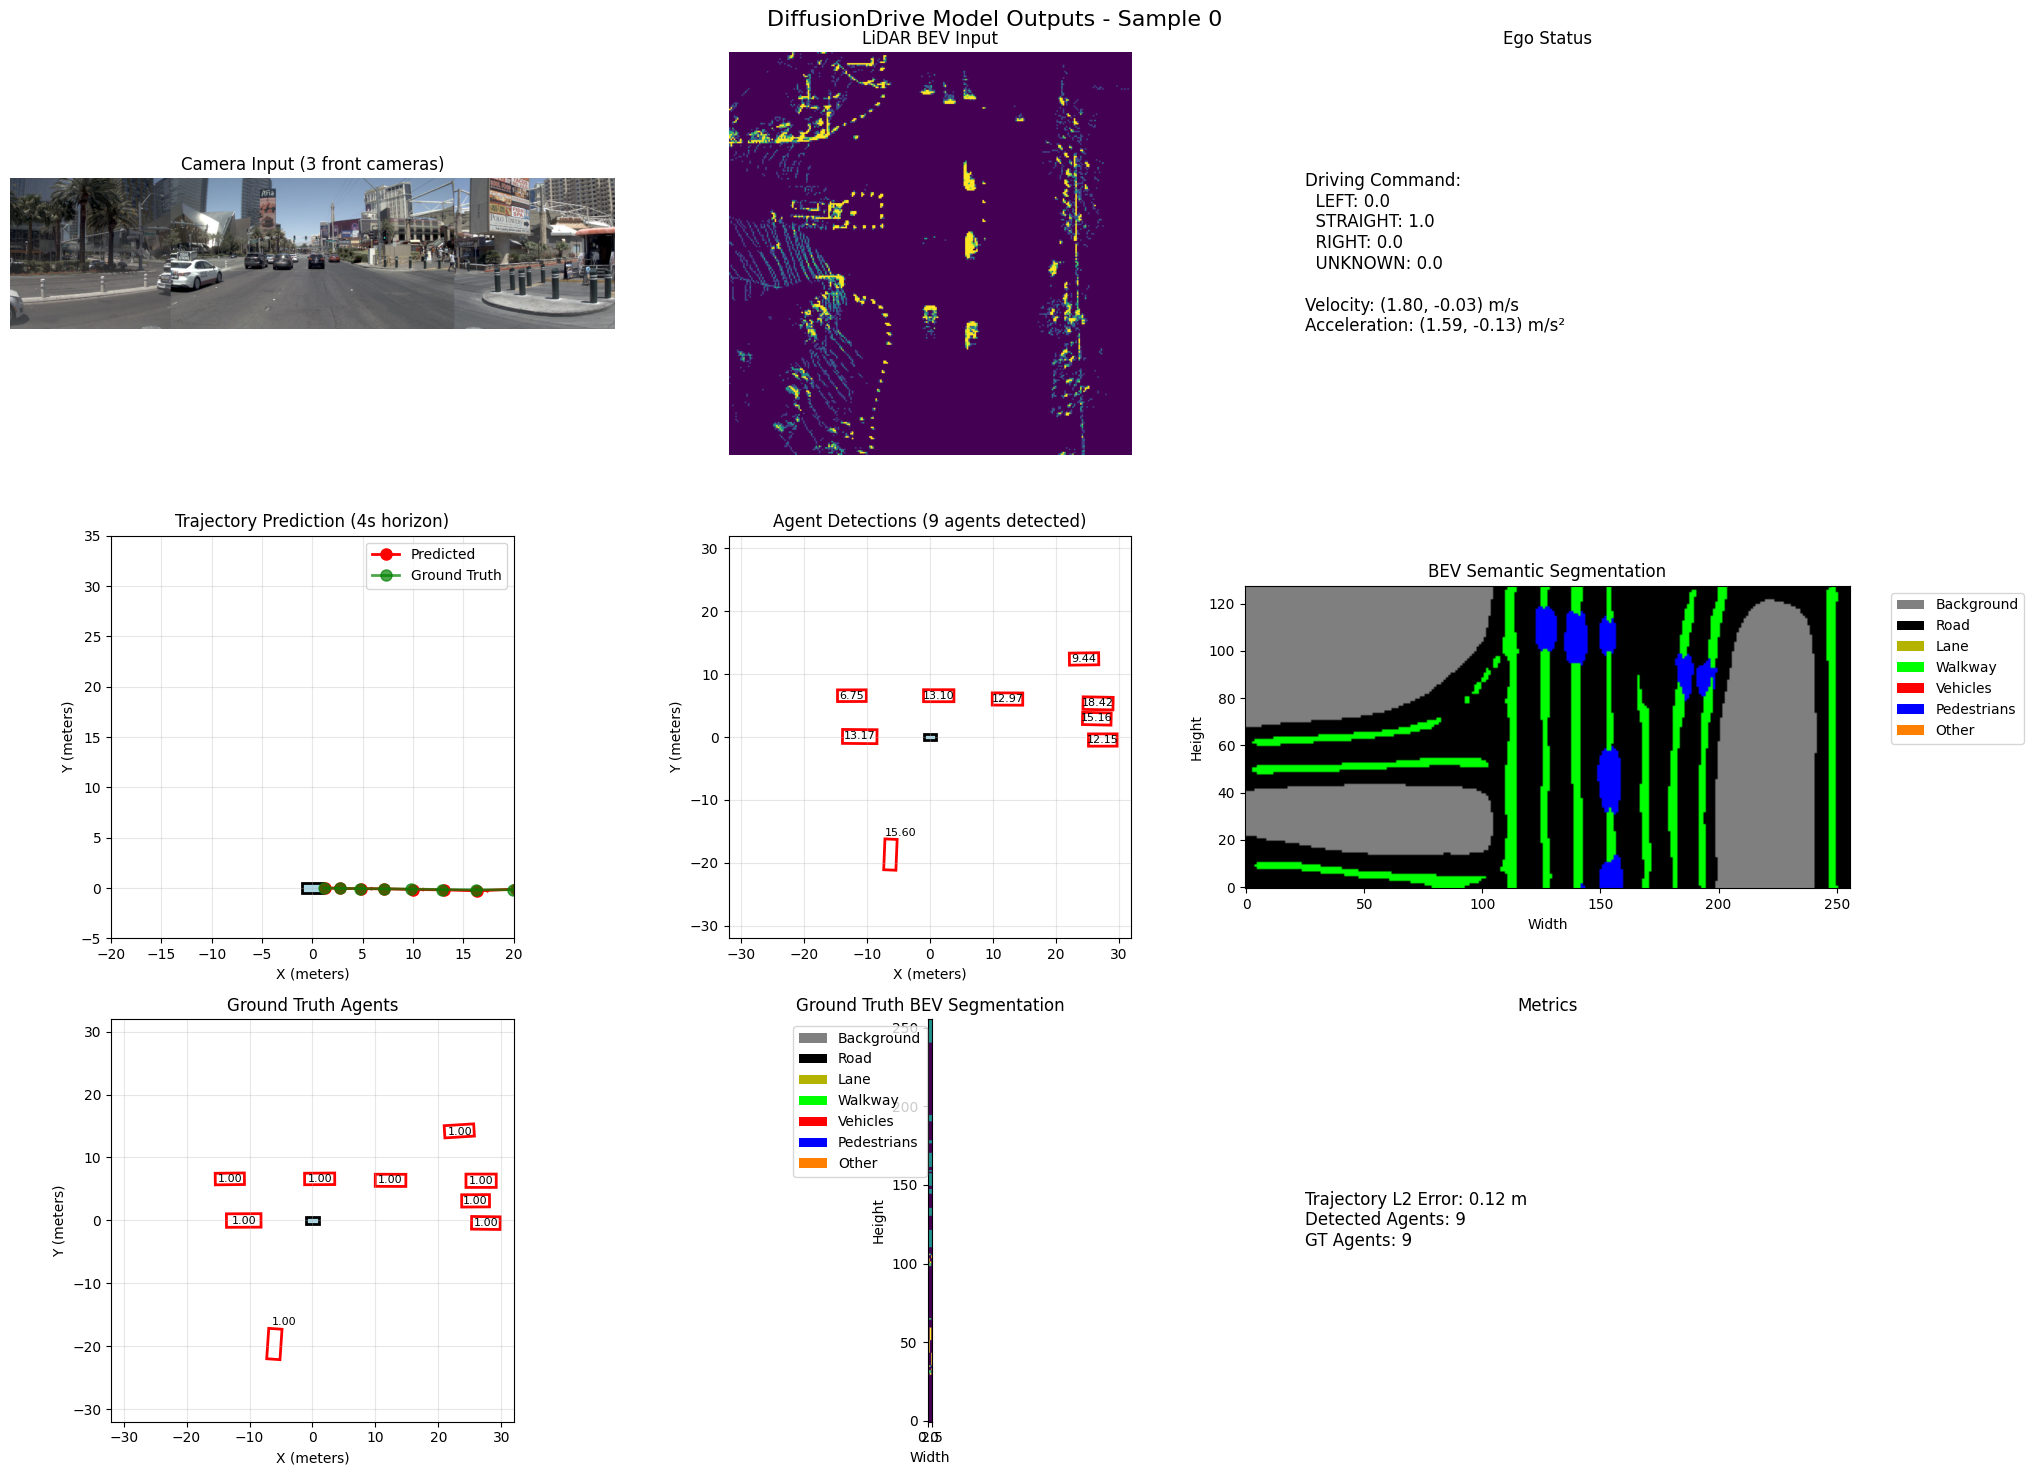

In [20]:
# Select a sample
sample_idx = 0

# Get features and targets
if sample_idx < len(cached_features):
    transfuser_feature = cached_features[sample_idx]
    transfuser_target = cached_targets[sample_idx]
    
    # Run visualization
    fig, predictions = visualize_model_outputs(
        model, transfuser_feature, transfuser_target, sample_idx
    )
    plt.show()
else:
    print(f"Sample index {sample_idx} out of range. Only {len(cached_features)} samples loaded.")

## 8. Interactive Sample Browser

In [21]:
from ipywidgets import interact, IntSlider

def browse_samples(idx):
    """Interactive browser for model outputs."""
    # Get features and targets
    if idx < len(cached_features):
        transfuser_feature = cached_features[idx]
        transfuser_target = cached_targets[idx]
        
        # Visualize
        fig, _ = visualize_model_outputs(
            model, transfuser_feature, transfuser_target, idx
        )
        plt.show()
    else:
        print(f"Sample index {idx} out of range. Only {len(cached_features)} samples loaded.")

# Create interactive widget
if len(cached_features) > 0:
    interact(browse_samples, 
             idx=IntSlider(min=0, max=min(100, len(cached_features)-1), 
                          step=1, value=0, description='Sample:'))
else:
    print("No samples loaded for browsing")

interactive(children=(IntSlider(value=0, description='Sample:', max=49), Output()), _dom_classes=('widget-inte…

In [22]:
def create_trajectory_animation(model, features_sequence, targets_sequence=None):
    """Create animation showing trajectory prediction over time."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Initialize plots
    ax1.set_xlim(-30, 30)
    ax1.set_ylim(-10, 50)
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.set_title('Trajectory Predictions Over Time')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Camera view
    camera_img = ax2.imshow(np.zeros((256, 1024, 3)))
    ax2.set_title('Camera View')
    ax2.axis('off')
    
    # Plot elements
    pred_line, = ax1.plot([], [], 'ro-', linewidth=2, markersize=8, label='Predicted')
    gt_line, = ax1.plot([], [], 'go-', linewidth=2, markersize=8, alpha=0.7, label='Ground Truth')
    ego_rect = patches.Rectangle((-1, -0.5), 2, 1, 
                                linewidth=2, edgecolor='black', 
                                facecolor='lightblue')
    ax1.add_patch(ego_rect)
    ax1.legend()
    
    def animate(frame):
        # Get current features
        feature = features_sequence[frame]
        
        # Run inference
        predictions = run_model_inference(model, feature)
        
        # Update trajectory
        pred_x = predictions['trajectory'][:, 0]
        pred_y = predictions['trajectory'][:, 1]
        pred_line.set_data(pred_x, pred_y)
        
        # Update ground truth if available
        if targets_sequence:
            gt = targets_sequence[frame]
            gt_x = gt['trajectory'].numpy()[:, 0]
            gt_y = gt['trajectory'].numpy()[:, 1]
            gt_line.set_data(gt_x, gt_y)
        
        # Update camera view
        cam_img = feature['camera_feature'].numpy().transpose(1, 2, 0)
        cam_img = (cam_img - cam_img.min()) / (cam_img.max() - cam_img.min())
        camera_img.set_array(cam_img)
        
        return pred_line, gt_line, camera_img
    
    anim = FuncAnimation(fig, animate, frames=len(features_sequence),
                        interval=500, blit=True, repeat=True)
    
    plt.close(fig)
    return HTML(anim.to_jshtml())

# Example: Create animation for first 10 frames
if len(cached_features) >= 10:
    features_seq = cached_features[:10]
    targets_seq = cached_targets[:10]
    
    print("Creating trajectory animation...")
    animation_html = create_trajectory_animation(model, features_seq, targets_seq)
    display(animation_html)
else:
    print("Not enough samples for animation")

Creating trajectory animation...


/tmp/ipykernel_2924172/3069185163.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'camera_feature': torch.tensor(transfuser_feature['camera_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'lidar_feature': torch.tensor(transfuser_feature['lidar_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'status_feature': torch.tensor(transfuser_feature['status_feature']).unsqueeze(0).to(device),
/tm

Evaluating 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2924172/3069185163.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'camera_feature': torch.tensor(transfuser_feature['camera_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'lidar_feature': torch.tensor(transfuser_feature['lidar_feature']).unsqueeze(0).to(device),
/tmp/ipykernel_2924172/3069185163.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'status_feature': torch.tensor(transfuser_feature['status_f

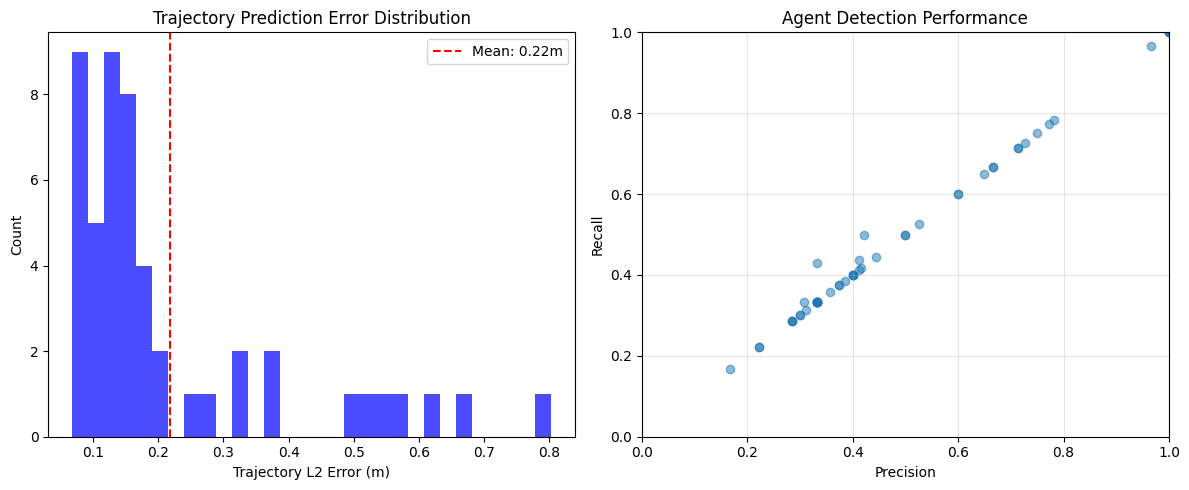


Evaluation Results:
trajectory_error_mean: 0.218
trajectory_error_std: 0.176
detection_precision_mean: 0.494
detection_recall_mean: 0.498


In [23]:
def evaluate_batch(model, num_samples=None):
    """Evaluate model on a batch of samples and compute statistics."""
    
    if num_samples is None:
        num_samples = len(cached_features)
    else:
        num_samples = min(num_samples, len(cached_features))
    
    # Metrics storage
    trajectory_errors = []
    detection_precisions = []
    detection_recalls = []
    
    print(f"Evaluating {num_samples} samples...")
    
    for idx in tqdm(range(num_samples)):
        # Get features and targets
        feature = cached_features[idx]
        target = cached_targets[idx]
        
        # Run inference
        predictions = run_model_inference(model, feature, target)
        
        # Compute trajectory error
        if hasattr(target['trajectory'], 'numpy'):
            gt_traj = target['trajectory'].numpy()
        else:
            gt_traj = target['trajectory']
            
        traj_error = np.mean(np.linalg.norm(
            predictions['trajectory'][:, :2] - gt_traj[:, :2], 
            axis=1
        ))
        trajectory_errors.append(traj_error)
        
        # Compute detection metrics
        pred_detections = predictions['agent_labels'] > 0.5
        
        if hasattr(target['agent_labels'], 'numpy'):
            gt_detections = target['agent_labels'].numpy() > 0.5
        else:
            gt_detections = target['agent_labels'] > 0.5
        
        if np.any(pred_detections) and np.any(gt_detections):
            tp = np.sum(pred_detections & gt_detections)
            fp = np.sum(pred_detections & ~gt_detections)
            fn = np.sum(~pred_detections & gt_detections)
            
            precision = tp / (tp + fp + 1e-6)
            recall = tp / (tp + fn + 1e-6)
            
            detection_precisions.append(precision)
            detection_recalls.append(recall)
    
    # Compute statistics
    results = {
        'trajectory_error_mean': np.mean(trajectory_errors),
        'trajectory_error_std': np.std(trajectory_errors),
        'detection_precision_mean': np.mean(detection_precisions) if detection_precisions else 0,
        'detection_recall_mean': np.mean(detection_recalls) if detection_recalls else 0,
    }
    
    # Plot distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.hist(trajectory_errors, bins=30, alpha=0.7, color='blue')
    ax1.axvline(results['trajectory_error_mean'], color='red', 
               linestyle='--', label=f'Mean: {results["trajectory_error_mean"]:.2f}m')
    ax1.set_xlabel('Trajectory L2 Error (m)')
    ax1.set_ylabel('Count')
    ax1.set_title('Trajectory Prediction Error Distribution')
    ax1.legend()
    
    if detection_precisions:
        ax2.scatter(detection_precisions, detection_recalls, alpha=0.5)
        ax2.set_xlabel('Precision')
        ax2.set_ylabel('Recall')
        ax2.set_title('Agent Detection Performance')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No detection data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run batch evaluation
if len(cached_features) > 0:
    evaluation_results = evaluate_batch(model, num_samples=min(50, len(cached_features)))
    
    print("\nEvaluation Results:")
    for key, value in evaluation_results.items():
        print(f"{key}: {value:.3f}")
else:
    print("No samples loaded for evaluation")

## 10. Batch Evaluation and Statistics

## 11. Save Visualization Results

In [24]:
# def save_visualization_report(model, output_dir='visualization_results', num_samples=10):
#     """Save visualization results to files."""
    
#     output_path = Path(output_dir)
#     output_path.mkdir(exist_ok=True)
    
#     num_samples = min(num_samples, len(cached_features))
#     print(f"Saving visualizations to {output_path}...")
    
#     for idx in tqdm(range(num_samples)):
#         # Get features and targets
#         feature = cached_features[idx]
#         target = cached_targets[idx]
        
#         # Create visualization
#         fig, predictions = visualize_model_outputs(
#             model, feature, target, idx
#         )
        
#         # Save figure
#         fig.savefig(output_path / f'sample_{idx:04d}.png', dpi=150, bbox_inches='tight')
#         plt.close(fig)
        
#         # Save predictions
#         np.savez(output_path / f'predictions_{idx:04d}.npz', **predictions)
    
#     print(f"Saved {num_samples} visualizations to {output_path}")

# # Save some examples
# if len(cached_features) > 0:
#     save_visualization_report(model, num_samples=min(5, len(cached_features)))
# else:
#     print("No samples loaded to save")

## Summary

This notebook provides comprehensive tools for visualizing DiffusionDrive model outputs:

1. **Model Loading**: Load trained checkpoints and prepare for inference
2. **Data Loading**: Access cached validation data
3. **Visualization Tools**:
   - Trajectory prediction vs ground truth
   - Agent detection bounding boxes
   - BEV semantic segmentation
4. **Interactive Browser**: Explore different samples
5. **Animations**: Visualize predictions over time
6. **Batch Evaluation**: Compute statistics across multiple samples
7. **Export**: Save visualizations for reports

The model successfully combines perception and planning, producing interpretable outputs for autonomous driving.